<a href="https://colab.research.google.com/github/mf2056/Dissertation/blob/main/Baseline_RF(Bayesian).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.6 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [5]:
X_train = np.load('/content/drive/MyDrive/X_train.npy')
Y_train_lab = np.load('/content/drive/MyDrive/Y_train_labels.npy')
X_test = np.load('/content/drive/MyDrive/X_test.npy')
Y_test_lab = np.load('/content/drive/MyDrive/Y_test_labels.npy')

In [6]:
# Flatten: Get the average value of each band across the patch
X_train_rf = X_train.mean(axis=(1, 2))
X_test_rf = X_test.mean(axis=(1, 2))

print(f"RF Training Input Shape: {X_train_rf.shape}")
print(f"RF Testing Input Shape:  {X_test_rf.shape}")

RF Training Input Shape: (639, 7)
RF Testing Input Shape:  (125, 7)


In [15]:
# Define the search space
search_space = {
    'n_estimators': Integer(50, 500),
    'max_depth': Integer(5, 50),
    'min_samples_split': Integer(2, 10),
    'max_features': Categorical(['sqrt', 'log2', None])
}

# Initialize RF
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Setup Bayesian Search
opt = BayesSearchCV(
    estimator=rf,
    search_spaces=search_space,
    n_iter=20,
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=20
)

print("Searching for the best hyperparameters...")
opt.fit(X_train_rf, Y_train_lab)

print(f"\nBest Parameters: {opt.best_params_}")

Searching for the best hyperparameters...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 fold

In [16]:
best_rf = opt.best_estimator_
y_pred = best_rf.predict(X_test_rf)

# Make sure these names match your label order (0, 1, 2, 3, 4, 5)
target_names = ['Tree cover', 'Shrubland', 'Grassland', 'Cropland', 'Built-up', 'Permanent water']

# Final predictions
train_preds = best_rf.predict(X_train_rf)
test_preds = best_rf.predict(X_test_rf)

# Calculate metrics
train_acc = accuracy_score(Y_train_lab, train_preds)
test_acc = accuracy_score(Y_test_lab, test_preds)
test_f1 = f1_score(Y_test_lab, test_preds, average='macro')

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Macro F1:  {test_f1:.4f}")

print(classification_report(Y_test_lab, y_pred, target_names=target_names))

Train Accuracy: 0.8560
Test Accuracy:  0.8080
Test Macro F1:  0.7808
                 precision    recall  f1-score   support

     Tree cover       0.55      1.00      0.71         6
      Shrubland       0.67      0.77      0.71        13
      Grassland       0.81      0.45      0.58        29
       Cropland       0.87      0.96      0.92        28
       Built-up       0.76      0.86      0.81        22
Permanent water       0.96      0.96      0.96        27

       accuracy                           0.81       125
      macro avg       0.77      0.83      0.78       125
   weighted avg       0.82      0.81      0.80       125



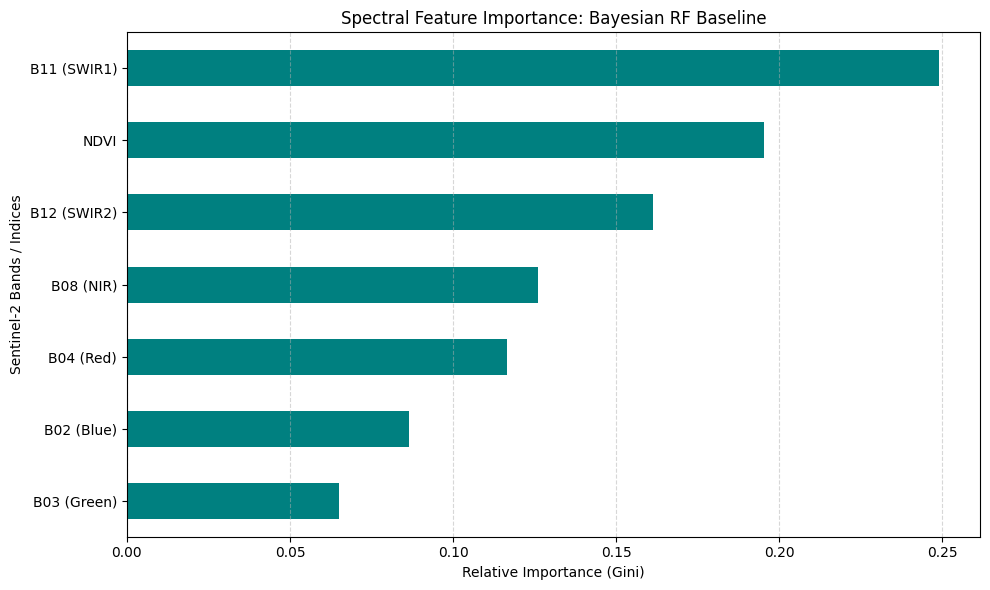

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

band_names = [
    'B04 (Red)',
    'B03 (Green)',
    'B02 (Blue)',
    'B08 (NIR)',
    'B11 (SWIR1)',
    'B12 (SWIR2)',
    'NDVI'
]

# Get the importance scores from your best RF model
importances = best_rf.feature_importances_

# Create the series with the correct labels
feat_importances = pd.Series(importances, index=band_names)

# Plotting
plt.figure(figsize=(10,6))
feat_importances.sort_values(ascending=True).plot(kind='barh', color='teal')

plt.title("Spectral Feature Importance: Bayesian RF Baseline")
plt.xlabel("Relative Importance (Gini)")
plt.ylabel("Sentinel-2 Bands / Indices")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()